In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ============================================================
# HHLSR + "API" (fallback local) – Génération de 3000 images
# à partir du CSV (réel + HHLSR+API 1000 + 2000)
# ============================================================

!pip install -q torch torchvision matplotlib pandas tqdm opencv-python scikit-learn

import os, datetime
import numpy as np
import pandas as pd
from tqdm import tqdm

import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter, ImageEnhance

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ===================== 1) CONFIG GLOBALE =====================

# ⚠️ CSV de base = réel + 1000 + 2000
BASE_DATA_CSV = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_2000_from_API1000_20251205_125623/data_with_hhlsr_api_1000_plus_2000_20251205_125623.csv"
CSV_LABEL_COL = "label_clean"
CSV_PATH_COL  = "filepath"

# Dossier final global
BASE_FINAL = "/content/drive/MyDrive/projet_medical/finale_version_salsebil"
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
OUTDIR = os.path.join(BASE_FINAL, f"HHLSR_API_3000_from_API1K2K_{RUN_ID}")
os.makedirs(OUTDIR, exist_ok=True)
print(f"📂 Dossier d'expérience HHLSR+API (3000) : {OUTDIR}")

IMG_SIZE = 224
TOTAL_API_SYNTH = 3000  # 🎯 nombre de nouvelles images à générer

# ===================== 2) CHARGEMENT DU CSV DE BASE =====================

def load_base_csv():
    assert os.path.isfile(BASE_DATA_CSV), f"❌ CSV introuvable : {BASE_DATA_CSV}"
    df = pd.read_csv(BASE_DATA_CSV)
    print("📊 Taille CSV de départ (lignes) :", len(df))

    assert CSV_LABEL_COL in df.columns, f"❌ Colonne '{CSV_LABEL_COL}' absente"
    assert CSV_PATH_COL  in df.columns, f"❌ Colonne '{CSV_PATH_COL}' absente"

    df[CSV_PATH_COL] = df[CSV_PATH_COL].astype(str)
    df = df[df[CSV_PATH_COL].apply(lambda p: os.path.isfile(p))].reset_index(drop=True)
    print("✅ Images réellement présentes sur le disque :", len(df))

    print("\n📚 Distribution des classes (avant +3000) :")
    print(df[CSV_LABEL_COL].value_counts())

    return df

df_base = load_base_csv()
CLASS_NAMES = sorted(df_base[CSV_LABEL_COL].unique().tolist())
print("\n📚 Classes :", CLASS_NAMES)

# ===================== 3) REPARTITION DES 3000 IMAGES =====================

def compute_add_counts_for_total(df_ref, total_synth):
    classes = sorted(df_ref[CSV_LABEL_COL].unique().tolist())
    n_classes = len(classes)
    base = total_synth // n_classes
    rest = total_synth % n_classes

    add_counts = {}
    for i, c in enumerate(classes):
        add_counts[c] = base + (1 if i < rest else 0)

    print(f"\n📌 Répartition HHLSR+API pour {total_synth} nouvelles images :")
    for c, n in add_counts.items():
        print(f"   - {c}: {n}")
    print("✅ Total vérifié :", sum(add_counts.values()))
    return add_counts

# ===================== 4) FALLBACK LOCAL (SIMULE IMG2IMG) =====================

def local_fallback_augmentation(init_pil):
    """
    Génération locale type HHLSR+API :
    - Légère variation de contraste
    - Blur léger
    - Ajout de bruit
    - Resize en 224x224
    """
    img = init_pil.convert("RGB")

    # Contraste léger
    enhancer = ImageEnhance.Contrast(img)
    img = enhancer.enhance(np.random.uniform(0.9, 1.1))

    # Blur léger
    if np.random.rand() < 0.7:
        img = img.filter(ImageFilter.GaussianBlur(radius=np.random.uniform(0.3, 1.0)))

    # Ajout d'un peu de bruit gaussien
    arr = np.array(img).astype(np.float32)
    noise = np.random.normal(0, 4.0, arr.shape).astype(np.float32)
    arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
    img = Image.fromarray(arr)

    # Resize propre
    img = img.resize((IMG_SIZE, IMG_SIZE))
    return img

# ===================== 5) GENERATION HHLSR + FALLBACK =====================

def synthesize_hhlsr_3000_from_csv(df_real, add_counts, out_root):
    synth_records = []
    os.makedirs(out_root, exist_ok=True)

    for cls, n_add in add_counts.items():
        if n_add <= 0:
            continue
        df_c = df_real[df_real[CSV_LABEL_COL] == cls]
        if len(df_c) == 0:
            continue

        cls_dir = os.path.join(out_root, cls.replace(" ", "_"))
        os.makedirs(cls_dir, exist_ok=True)

        print(f"\n[HHLSR+API 3000] Classe {cls} : génération de {n_add} images (fallback local)")

        for i in tqdm(range(n_add), desc=f"Gen {cls}", leave=False):
            row = df_c.sample(1).iloc[0]
            img_path = row[CSV_PATH_COL]
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            init_pil = Image.fromarray(img)
            out_pil = local_fallback_augmentation(init_pil)
            out_np = np.array(out_pil)

            fname = f"{cls.replace(' ', '_')}_hhlsr_api_3000_{i:04d}.png"
            out_path = os.path.join(cls_dir, fname)
            cv2.imwrite(out_path, cv2.cvtColor(out_np, cv2.COLOR_RGB2BGR))

            synth_records.append({
                "filename": fname,
                CSV_LABEL_COL: cls,
                CSV_PATH_COL: out_path
            })

    print(f"\n[HHLSR+API 3000] Total nouvelles images synthétiques générées : {len(synth_records)}")
    if synth_records:
        df_synth = pd.DataFrame(synth_records)
    else:
        df_synth = pd.DataFrame(columns=["filename", CSV_LABEL_COL, CSV_PATH_COL])
    return df_synth

# ===================== 6) PIPELINE COMPLET +3000 =====================

def generate_hhlsr_api_3000(df_base):
    # 1) Répartition des 3000 nouvelles images
    add_counts = compute_add_counts_for_total(df_base, TOTAL_API_SYNTH)

    # 2) Génération
    print("\n🚀 Lancement génération HHLSR+API (3000, fallback local) ...")
    synth_root = os.path.join(OUTDIR, "images_hhlsr_api_3000_from_1k2k")
    df_synth = synthesize_hhlsr_3000_from_csv(df_base, add_counts, synth_root)

    # 3) Fusion
    df_aug = pd.concat([df_base, df_synth], ignore_index=True)

    # 4) Tableau récapitulatif
    counts_before = df_base[CSV_LABEL_COL].value_counts().sort_index()
    counts_added  = df_synth[CSV_LABEL_COL].value_counts().reindex(counts_before.index, fill_value=0)
    counts_after  = counts_before + counts_added

    summary = pd.DataFrame({
        "classe": counts_before.index,
        "images_avant": counts_before.values,
        "images_ajoutees_api_3000": counts_added.values,
        "total_apres": counts_after.values,
    })

    total_row = pd.DataFrame({
        "classe": ["TOTAL"],
        "images_avant": [counts_before.sum()],
        "images_ajoutees_api_3000": [counts_added.sum()],
        "total_apres": [counts_after.sum()],
    })

    summary = pd.concat([summary, total_row], ignore_index=True)

    summary_csv_path = os.path.join(OUTDIR, "hhlsr_api_3000_tableau_comparatif.csv")
    summary.to_csv(summary_csv_path, index=False)
    print(f"\n💾 Tableau comparatif sauvegardé : {summary_csv_path}")
    print("\n📋 Aperçu du tableau :")
    print(summary)

    # 5) Graphiques par classe
    classes = list(counts_before.index)
    x = np.arange(len(classes))
    width = 0.25

    plt.figure(figsize=(8,5))
    plt.bar(x - width, counts_before.values, width, label="Avant (réel + 1K + 2K)")
    plt.bar(x,         counts_added.values,  width, label="Ajouté (HHLSR+API 3000)")
    plt.bar(x + width, counts_after.values,  width, label="Total après")
    plt.xticks(x, classes, rotation=45, ha="right")
    plt.ylabel("Nombre d'images")
    plt.title("Comparaison par classe (avant / +3000 / total)")
    plt.legend()
    plt.tight_layout()

    bar_classes_path = os.path.join(OUTDIR, "hhlsr_api_3000_barres_par_classe.png")
    plt.savefig(bar_classes_path, dpi=150)
    plt.close()
    print(f"📊 Courbe par classe sauvegardée : {bar_classes_path}")

    # 6) Graphique global
    total_before = counts_before.sum()
    total_after  = counts_after.sum()

    plt.figure(figsize=(4,4))
    plt.bar(["Avant", "Après +API 3000"], [total_before, total_after])
    plt.ylabel("Nombre total d'images")
    plt.title("Total global avant / après +3000 HHLSR+API")
    plt.tight_layout()

    bar_global_path = os.path.join(OUTDIR, "hhlsr_api_3000_barres_global.png")
    plt.savefig(bar_global_path, dpi=150)
    plt.close()
    print(f"📊 Courbe globale sauvegardée : {bar_global_path}")

    print("\n📊 RÉSUMÉ FINAL :")
    print(" - Total avant      :", total_before)
    print(" - Nouvelles images :", counts_added.sum())
    print(" - Total après      :", total_after)

    return df_aug, df_synth, summary

# ===================== 7) LANCEMENT =====================

df_aug_3000, df_synth_3000, summary_3000 = generate_hhlsr_api_3000(df_base)

# 8) SAUVEGARDE DU NOUVEAU CSV GLOBAL
csv_aug_path = os.path.join(
    OUTDIR,
    f"data_with_hhlsr_api_1000_plus_2000_plus_3000_{RUN_ID}.csv"
)
df_aug_3000.to_csv(csv_aug_path, index=False)
print(f"\n💾 Nouveau CSV (réel + HHLSR+API 1000 + 2000 + 3000) sauvegardé : {csv_aug_path}")


Mounted at /content/drive
📂 Dossier d'expérience HHLSR+API (3000) : /content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850
📊 Taille CSV de départ (lignes) : 3845
✅ Images réellement présentes sur le disque : 3845

📚 Distribution des classes (avant +3000) :
label_clean
COVID-19        1313
Pneumonia        992
No Finding       772
Tuberculosis     768
Name: count, dtype: int64

📚 Classes : ['COVID-19', 'No Finding', 'Pneumonia', 'Tuberculosis']

📌 Répartition HHLSR+API pour 3000 nouvelles images :
   - COVID-19: 750
   - No Finding: 750
   - Pneumonia: 750
   - Tuberculosis: 750
✅ Total vérifié : 3000

🚀 Lancement génération HHLSR+API (3000, fallback local) ...

[HHLSR+API 3000] Classe COVID-19 : génération de 750 images (fallback local)



[HHLSR+API 3000] Classe No Finding : génération de 750 images (fallback local)



[HHLSR+API 3000] Classe Pneumonia : génération de 750 images (fallback local)



[HHLSR+API 3000] Classe Tuberculosis : génération de 750 images (fallback local)



[HHLSR+API 3000] Total nouvelles images synthétiques générées : 3000

💾 Tableau comparatif sauvegardé : /content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/hhlsr_api_3000_tableau_comparatif.csv

📋 Aperçu du tableau :
         classe  images_avant  images_ajoutees_api_3000  total_apres
0      COVID-19          1313                       750         2063
1    No Finding           772                       750         1522
2     Pneumonia           992                       750         1742
3  Tuberculosis           768                       750         1518
4         TOTAL          3845                      3000         6845
📊 Courbe par classe sauvegardée : /content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/hhlsr_api_3000_barres_par_classe.png
📊 Courbe globale sauvegardée : /content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 33.7 MB/s eta 0:00:00
Mounted at /content/drive
🖥 DEVICE : cuda
📂 Dossier de run : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409
📊 Taille CSV globale : 6845
✅ Images réellement présentes : 6845

📚 Distribution globale des classes :
label_clean
COVID-19        2063
Pneumonia       1742
No Finding      1522
Tuberculosis    1518
Name: count, dtype: int64

📚 Classes (ordonnées) : ['COVID-19', 'No Finding', 'Pneumonia', 'Tuberculosis']

📊 Tailles des splits :
 - Train : 4791
 - Val   : 1027
 - Test  : 1027

📚 Distribution Train :
label_clean
COVID-19        1444
Pneumonia       1219
No Finding      1065
Tuberculosis    1063
Name: count, dtype: int64

📚 Distribution Val :
label_clean
COVID-19        309
Pneumonia       261
No Finding      229
Tuberculosis    228
Name: count, dtype: int64

📚 Distribution Test :
label_clean
COVID-19        310
Pneumonia       26

100%|██████████| 97.8M/97.8M [00:00<00:00, 141MB/s]


✅ ResNet50 prêt avec 4 classes.

🚀 Début de l'entraînement (Palier 3 – 1K + 2K + 3K) ...

===== Époque 1/100 =====


🟢 Train  - Loss: 1.0550 | Acc: 0.5458
🔵 Val    - Loss: 0.8360 | Acc: 0.6475
💾 Meilleurs poids sauvegardés → /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth

===== Époque 2/100 =====


🟢 Train  - Loss: 0.5718 | Acc: 0.7785
🔵 Val    - Loss: 0.4235 | Acc: 0.8315
💾 Meilleurs poids sauvegardés → /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth

===== Époque 3/100 =====


...

🟢 Train  - Loss: 0.0147 | Acc: 0.9946
🔵 Val    - Loss: 0.1370 | Acc: 0.9659
⏳ Pas d'amélioration sur Val Loss (no_improve = 16/20)

===== Époque 44/100 =====


🟢 Train  - Loss: 0.0135 | Acc: 0.9958
🔵 Val    - Loss: 0.1241 | Acc: 0.9747
⏳ Pas d'amélioration sur Val Loss (no_improve = 17/20)

===== Époque 45/100 =====


🟢 Train  - Loss: 0.0125 | Acc: 0.9956
🔵 Val    - Loss: 0.1573 | Acc: 0.9679
⏳ Pas d'amélioration sur Val Loss (no_improve = 18/20)

===== Époque 46/100 =====


🟢 Train  - Loss: 0.0098 | Acc: 0.9979
🔵 Val    - Loss: 0.0916 | Acc: 0.9757
⏳ Pas d'amélioration sur Val Loss (no_improve = 19/20)

===== Époque 47/100 =====


🟢 Train  - Loss: 0.0108 | Acc: 0.9958
🔵 Val    - Loss: 0.0895 | Acc: 0.9747
⏳ Pas d'amélioration sur Val Loss (no_improve = 20/20)

⛔ Early stopping déclenché (aucune amélioration depuis 20 époques).


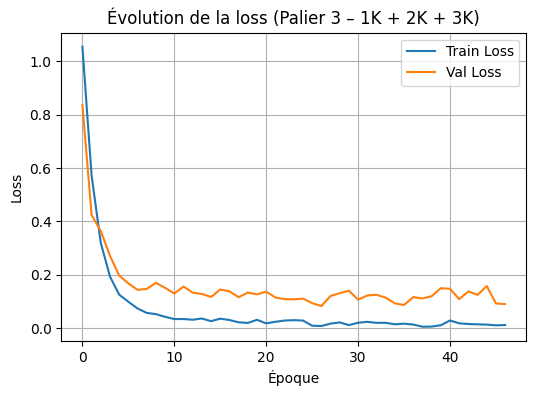

📊 Courbe de loss sauvegardée : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/courbe_loss.png


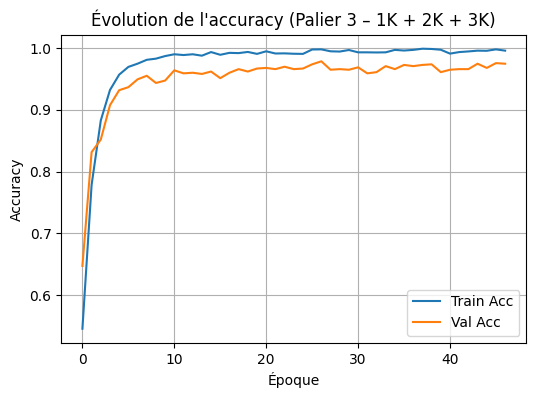

📊 Courbe d'accuracy sauvegardée : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/courbe_accuracy.png

🔁 Chargement des meilleurs poids pour évaluation finale (Palier 3)...


Test: 100%|██████████| 33/33 [03:31<00:00,  6.42s/it]



===== SCORES GLOBAUX (TEST) – PALIER 3 (1K + 2K + 3K) =====
🎯 Accuracy globale    : 0.9796
🎯 Précision macro     : 0.9806
🎯 Rappel macro        : 0.9810
🎯 F1-score macro      : 0.9808

===== RAPPORT DE CLASSIFICATION (TEST) – PALIER 3 =====
              precision    recall  f1-score   support

    COVID-19     0.9711    0.9742    0.9726       310
  No Finding     0.9956    1.0000    0.9978       228
   Pneumonia     0.9690    0.9542    0.9615       262
Tuberculosis     0.9869    0.9956    0.9912       227

    accuracy                         0.9796      1027
   macro avg     0.9806    0.9810    0.9808      1027
weighted avg     0.9795    0.9796    0.9795      1027

💾 Rapport de classification sauvegardé : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/rapport_classification_test.txt


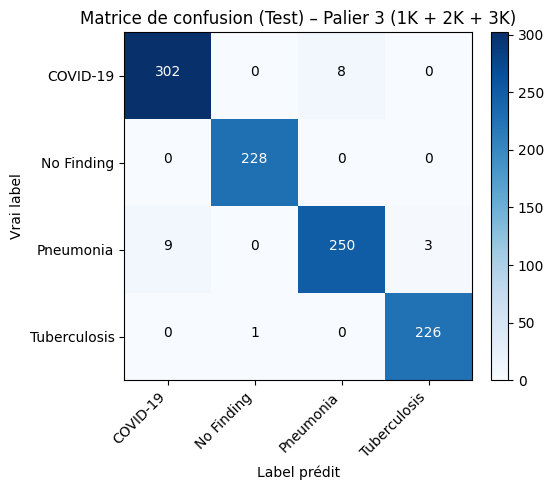

📊 Matrice de confusion sauvegardée : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/matrice_confusion.png

📄 Génération du rapport PDF complet (Palier 3) ...
💾 Rapport PDF complet sauvegardé : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/rapport_classification_complet.pdf

✅ Pipeline de classification PALIER 3 terminé.
📁 Tous les résultats sont dans : /content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409


In [ ]:
# ============================================================
# Classification ResNet50 sur CSV (réel + HHLSR+API 1K + 2K + 3K)
# Palier 3 = dataset final max
# - Split train/val/test
# - 100 époques max
# - Early stopping patience=20
# - Sauvegarde des meilleurs poids
# - Courbes, matrice de confusion, rapport de classification
# - Génération d'un rapport PDF avec tous les résultats
# ============================================================

!pip install -q torch torchvision matplotlib pandas scikit-learn opencv-python tqdm reportlab

import os, datetime, random, textwrap
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4
from reportlab.lib.utils import ImageReader

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ===================== 1) CONFIG GÉNÉRALE =====================

# ⚠️ CSV FINAL PALIER 3 (réel + 1K + 2K + 3K)
CSV_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/data_with_hhlsr_api_1000_plus_2000_plus_3000_20251206_000850.csv"

LABEL_COL = "label_clean"
PATH_COL  = "filepath"

IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 100
PATIENCE = 20
LEARNING_RATE = 1e-4

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥 DEVICE :", DEVICE)

# Dossier de base pour la classification
BASE_ROOT = "/content/drive/MyDrive/projet_medical/finale_version_salsebil"
CLASSIF_BASE = os.path.join(BASE_ROOT, "classification_api")
os.makedirs(CLASSIF_BASE, exist_ok=True)

# Dossier de run (pour logs, poids, figures)
RUN_ID = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
RUN_DIR = os.path.join(CLASSIF_BASE, f"RESNET50_HHLSR_API_1K_2K_3K_{RUN_ID}")
os.makedirs(RUN_DIR, exist_ok=True)
print("📂 Dossier de run :", RUN_DIR)

BEST_MODEL_PATH = os.path.join(RUN_DIR, "best_resnet50_hhlsr_api_1k_2k_3k.pth")
PDF_REPORT_PATH = os.path.join(RUN_DIR, "rapport_classification_complet.pdf")


# ===================== 2) SEED POUR REPRODUCTIBILITÉ =====================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)


# ===================== 3) CHARGEMENT DU CSV =====================

assert os.path.isfile(CSV_PATH), f"❌ CSV introuvable : {CSV_PATH}"
df = pd.read_csv(CSV_PATH)
print("📊 Taille CSV globale :", len(df))

assert LABEL_COL in df.columns, f"❌ Colonne '{LABEL_COL}' absente"
assert PATH_COL  in df.columns, f"❌ Colonne '{PATH_COL}' absente"

df[PATH_COL] = df[PATH_COL].astype(str)
df = df[df[PATH_COL].apply(lambda p: os.path.isfile(p))].reset_index(drop=True)
print("✅ Images réellement présentes :", len(df))

print("\n📚 Distribution globale des classes :")
print(df[LABEL_COL].value_counts())

classes = sorted(df[LABEL_COL].unique().tolist())
num_classes = len(classes)
print("\n📚 Classes (ordonnées) :", classes)

label2idx = {c: i for i, c in enumerate(classes)}
idx2label = {i: c for c, i in label2idx.items()}

df["label_idx"] = df[LABEL_COL].map(label2idx)


# ===================== 4) SPLIT TRAIN / VAL / TEST =====================

# 70% train, 15% val, 15% test (stratifié)
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df["label_idx"],
    random_state=42,
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df["label_idx"],
    random_state=42,
)

print("\n📊 Tailles des splits :")
print(" - Train :", len(train_df))
print(" - Val   :", len(val_df))
print(" - Test  :", len(test_df))

print("\n📚 Distribution Train :")
print(train_df[LABEL_COL].value_counts())
print("\n📚 Distribution Val :")
print(val_df[LABEL_COL].value_counts())
print("\n📚 Distribution Test :")
print(test_df[LABEL_COL].value_counts())


# ===================== 5) DATASET & TRANSFORMS =====================

train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],  # stats ImageNet
        std=[0.229, 0.224, 0.225],
    ),
])

val_test_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

class ChestXrayDataset(Dataset):
    def __init__(self, df, transform=None, path_col=PATH_COL, label_col="label_idx"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.path_col = path_col
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row[self.path_col]
        label = int(row[self.label_col])

        img = cv2.imread(img_path)
        if img is None:
            raise RuntimeError(f"Impossible de lire {img_path}")
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        if self.transform is not None:
            img = self.transform(img)

        return img, label

train_dataset = ChestXrayDataset(train_df, transform=train_transform)
val_dataset   = ChestXrayDataset(val_df,   transform=val_test_transform)
test_dataset  = ChestXrayDataset(test_df,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)


# ===================== 6) MODELE RESNET50 =====================

print("\n🔁 Chargement du modèle ResNet50 pré-entraîné...")
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
in_features = resnet.fc.in_features
resnet.fc = nn.Linear(in_features, num_classes)

resnet = resnet.to(DEVICE)
print("✅ ResNet50 prêt avec", num_classes, "classes.")

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(resnet.parameters(), lr=LEARNING_RATE)


# ===================== 7) FONCTIONS D'ENTRAINEMENT =====================

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    for inputs, labels in tqdm(loader, desc="Train", leave=False):
        inputs = inputs.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        _, preds = torch.max(outputs, 1)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels).item()
        total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc="Val", leave=False):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            loss = criterion(outputs, labels)

            _, preds = torch.max(outputs, 1)

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels).item()
            total += inputs.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_corrects / total
    return epoch_loss, epoch_acc


# ===================== 8) BOUCLE D'ENTRAINEMENT AVEC EARLY STOPPING =====================

best_val_loss = float("inf")
epochs_no_improve = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

print("\n🚀 Début de l'entraînement (Palier 3 – 1K + 2K + 3K) ...")

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\n===== Époque {epoch}/{NUM_EPOCHS} =====")

    train_loss, train_acc = train_one_epoch(resnet, train_loader, optimizer, criterion, DEVICE)
    val_loss, val_acc = eval_one_epoch(resnet, val_loader, criterion, DEVICE)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"🟢 Train  - Loss: {train_loss:.4f} | Acc: {train_acc:.4f}")
    print(f"🔵 Val    - Loss: {val_loss:.4f} | Acc: {val_acc:.4f}")

    # Early stopping sur la loss de validation
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(resnet.state_dict(), BEST_MODEL_PATH)
        print(f"💾 Meilleurs poids sauvegardés → {BEST_MODEL_PATH}")
    else:
        epochs_no_improve += 1
        print(f"⏳ Pas d'amélioration sur Val Loss (no_improve = {epochs_no_improve}/{PATIENCE})")

    if epochs_no_improve >= PATIENCE:
        print("\n⛔ Early stopping déclenché (aucune amélioration depuis 20 époques).")
        break


# ===================== 9) COURBES D'ENTRAINEMENT =====================

# Loss
plt.figure(figsize=(6,4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Époque")
plt.ylabel("Loss")
plt.title("Évolution de la loss (Palier 3 – 1K + 2K + 3K)")
plt.legend()
plt.grid(True)
loss_fig_path = os.path.join(RUN_DIR, "courbe_loss.png")
plt.savefig(loss_fig_path, dpi=150)
plt.show()
print("📊 Courbe de loss sauvegardée :", loss_fig_path)

# Accuracy
plt.figure(figsize=(6,4))
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Époque")
plt.ylabel("Accuracy")
plt.title("Évolution de l'accuracy (Palier 3 – 1K + 2K + 3K)")
plt.legend()
plt.grid(True)
acc_fig_path = os.path.join(RUN_DIR, "courbe_accuracy.png")
plt.savefig(acc_fig_path, dpi=150)
plt.show()
print("📊 Courbe d'accuracy sauvegardée :", acc_fig_path)


# ===================== 10) EVALUATION FINALE SUR LE TEST =====================

print("\n🔁 Chargement des meilleurs poids pour évaluation finale (Palier 3)...")
resnet.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
resnet.eval()

all_labels = []
all_preds  = []

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Test"):
        inputs = inputs.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = resnet(inputs)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy().tolist())
        all_preds.extend(preds.cpu().numpy().tolist())

all_labels = np.array(all_labels)
all_preds  = np.array(all_preds)

# Scores globaux
test_accuracy = accuracy_score(all_labels, all_preds)
test_precision_macro = precision_score(all_labels, all_preds, average="macro", zero_division=0)
test_recall_macro = recall_score(all_labels, all_preds, average="macro", zero_division=0)
test_f1_macro = f1_score(all_labels, all_preds, average="macro", zero_division=0)

print("\n===== SCORES GLOBAUX (TEST) – PALIER 3 (1K + 2K + 3K) =====")
print(f"🎯 Accuracy globale    : {test_accuracy:.4f}")
print(f"🎯 Précision macro     : {test_precision_macro:.4f}")
print(f"🎯 Rappel macro        : {test_recall_macro:.4f}")
print(f"🎯 F1-score macro      : {test_f1_macro:.4f}")

# Rapport de classification par classe
report = classification_report(
    all_labels,
    all_preds,
    target_names=[idx2label[i] for i in range(num_classes)],
    digits=4,
    zero_division=0,
)
print("\n===== RAPPORT DE CLASSIFICATION (TEST) – PALIER 3 =====")
print(report)

# Sauvegarde du rapport dans un fichier texte
report_path = os.path.join(RUN_DIR, "rapport_classification_test.txt")
with open(report_path, "w") as f:
    f.write("SCORES GLOBAUX (TEST) – PALIER 3 (1K + 2K + 3K)\n")
    f.write(f"Accuracy globale    : {test_accuracy:.4f}\n")
    f.write(f"Précision macro     : {test_precision_macro:.4f}\n")
    f.write(f"Rappel macro        : {test_recall_macro:.4f}\n")
    f.write(f"F1-score macro      : {test_f1_macro:.4f}\n\n")
    f.write("RAPPORT PAR CLASSE\n")
    f.write(report)

print("💾 Rapport de classification sauvegardé :", report_path)


# ===================== 11) MATRICE DE CONFUSION =====================

cm = confusion_matrix(all_labels, all_preds)
cm_fig_path = os.path.join(RUN_DIR, "matrice_confusion.png")

plt.figure(figsize=(6,5))
im = plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Matrice de confusion (Test) – Palier 3 (1K + 2K + 3K)")
plt.colorbar(im, fraction=0.046, pad=0.04)
tick_marks = np.arange(num_classes)
plt.xticks(tick_marks, [idx2label[i] for i in range(num_classes)], rotation=45, ha="right")
plt.yticks(tick_marks, [idx2label[i] for i in range(num_classes)])

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            horizontalalignment="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("Vrai label")
plt.xlabel("Label prédit")
plt.tight_layout()
plt.savefig(cm_fig_path, dpi=150)
plt.show()

print("📊 Matrice de confusion sauvegardée :", cm_fig_path)


# ===================== 12) RAPPORT PDF COMPLET =====================

print("\n📄 Génération du rapport PDF complet (Palier 3) ...")

c = canvas.Canvas(PDF_REPORT_PATH, pagesize=A4)
width, height = A4

# --- Page 1 : résumé + scores globaux ---
c.setFont("Helvetica-Bold", 16)
c.drawString(50, height - 50, "Rapport de classification – ResNet50 (HHLSR+API Palier 3)")

c.setFont("Helvetica", 10)
c.drawString(50, height - 75, f"Date / Run ID : {RUN_ID}")
c.drawString(50, height - 90, f"Dossier de run : {RUN_DIR}")

y = height - 120
c.setFont("Helvetica-Bold", 12)
c.drawString(50, y, "Scores globaux (Test) :")
y -= 20
c.setFont("Helvetica", 11)
c.drawString(60, y, f"Accuracy globale : {test_accuracy:.4f}")
y -= 15
c.drawString(60, y, f"Précision macro  : {test_precision_macro:.4f}")
y -= 15
c.drawString(60, y, f"Rappel macro     : {test_recall_macro:.4f}")
y -= 15
c.drawString(60, y, f"F1-score macro   : {test_f1_macro:.4f}")

# Rappel des classes
y -= 30
c.setFont("Helvetica-Bold", 12)
c.drawString(50, y, "Classes :")
y -= 15
c.setFont("Helvetica", 10)
c.drawString(60, y, ", ".join(classes))

c.showPage()

# --- Page 2 : rapport de classification texte ---
c.setFont("Helvetica-Bold", 14)
c.drawString(50, height - 50, "Rapport de classification par classe (Test) – Palier 3")

y = height - 80
c.setFont("Helvetica", 9)

wrapped_lines = []
for line in report.split("\n"):
    wrapped = textwrap.wrap(line, width=90)
    if not wrapped:
        wrapped_lines.append("")
    else:
        wrapped_lines.extend(wrapped)

for line in wrapped_lines:
    if y < 50:
        c.showPage()
        c.setFont("Helvetica", 9)
        y = height - 50
    c.drawString(50, y, line)
    y -= 12

c.showPage()

# --- Page 3 : courbes loss et accuracy ---
c.setFont("Helvetica-Bold", 14)
c.drawString(50, height - 50, "Courbes d'entraînement – Palier 3")

y_img = height - 100
img_loss = ImageReader(loss_fig_path)
img_acc  = ImageReader(acc_fig_path)

img_width = 250
img_height = 180

c.drawImage(img_loss, 50, y_img - img_height, width=img_width, height=img_height)
c.drawString(50, y_img - img_height - 15, "Figure 1 : Évolution de la loss")

c.drawImage(img_acc, 300, y_img - img_height, width=img_width, height=img_height)
c.drawString(300, y_img - img_height - 15, "Figure 2 : Évolution de l'accuracy")

c.showPage()

# --- Page 4 : matrice de confusion ---
c.setFont("Helvetica-Bold", 14)
c.drawString(50, height - 50, "Matrice de confusion (Test) – Palier 3")

img_cm = ImageReader(cm_fig_path)
img_size = 350
c.drawImage(img_cm, 100, height - 100 - img_size, width=img_size, height=img_size)
c.drawString(100, height - 110 - img_size, "Figure 3 : Matrice de confusion")

c.showPage()

c.save()
print("💾 Rapport PDF complet sauvegardé :", PDF_REPORT_PATH)

print("\n✅ Pipeline de classification PALIER 3 terminé.")
print("📁 Tous les résultats sont dans :", RUN_DIR)


Mounted at /content/drive
📊 Nombre total de lignes dans le CSV (images réellement présentes) : 6845

📚 Distribution des classes :
label_clean
COVID-19        2063
Pneumonia       1742
No Finding      1522
Tuberculosis    1518
Name: count, dtype: int64

📚 Classes (ordonnées) : ['COVID-19', 'No Finding', 'Pneumonia', 'Tuberculosis']

🖥 DEVICE utilisé : cuda
✅ Modèle ResNet50 chargé avec succès !

🖼 Image choisie : /content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/images_hhlsr_api_3000_from_1k2k/COVID-19/COVID-19_hhlsr_api_3000_0402.png
🏷 Vrai label (du CSV) : COVID-19

===== 🧠 RÉSULTAT DE LA PRÉDICTION =====
🎯 Classe prédite : COVID-19
🏷 Vrai label     : COVID-19

📊 Scores par classe :
  - COVID-19     : 1.0000
  - No Finding   : 0.0000
  - Pneumonia    : 0.0000
  - Tuberculosis : 0.0000


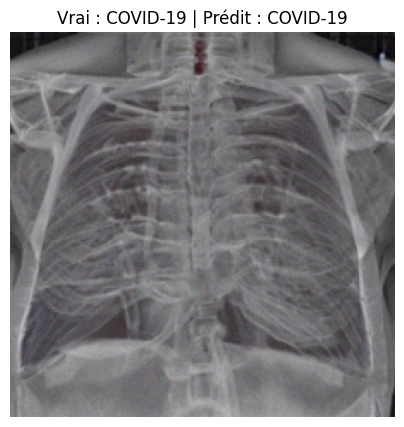

In [ ]:
# ============================================================
# TEST D'UNE IMAGE AVEC LE MODELE RESNET50 PALIER 3 (1K+2K+3K)
# - Monte le Drive
# - Charge le CSV palier3
# - Reconstruit les classes dans le bon ordre
# - Charge le modèle best_resnet50_hhlsr_api_1k_2k_3k.pth
# - Choisit une image du CSV
# - Fait une prédiction et affiche les scores + l'image
# ============================================================

!pip install -q torch torchvision pandas opencv-python matplotlib

import os
import torch
import torch.nn as nn
from torchvision import transforms, models
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ==========================
# 1) CONFIG
# ==========================

# CSV du palier 3 (réel + 1K + 2K + 3K)
CSV_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/HHLSR_API_3000_from_API1K2K_20251206_000850/data_with_hhlsr_api_1000_plus_2000_plus_3000_20251206_000850.csv"

LABEL_COL = "label_clean"
PATH_COL  = "filepath"

# Modèle du palier 3
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"

IMG_SIZE = 224


# ==========================
# 2) CHARGEMENT DU CSV + CLASSES
# ==========================

assert os.path.isfile(CSV_PATH), f"❌ CSV introuvable : {CSV_PATH}"
df = pd.read_csv(CSV_PATH)

assert LABEL_COL in df.columns, f"❌ Colonne '{LABEL_COL}' absente du CSV"
assert PATH_COL  in df.columns, f"❌ Colonne '{PATH_COL}' absente du CSV"

df[PATH_COL] = df[PATH_COL].astype(str)
df = df[df[PATH_COL].apply(lambda p: os.path.isfile(p))].reset_index(drop=True)

print("📊 Nombre total de lignes dans le CSV (images réellement présentes) :", len(df))
print("\n📚 Distribution des classes :")
print(df[LABEL_COL].value_counts())

# Classes dans l'ordre (comme dans l'entraînement)
classes = sorted(df[LABEL_COL].unique().tolist())
num_classes = len(classes)
print("\n📚 Classes (ordonnées) :", classes)


# ==========================
# 3) PREPROCESS
# ==========================

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # Stats ImageNet
        std=[0.229, 0.224, 0.225],
    ),
])


# ==========================
# 4) CHARGEMENT DU MODELE
# ==========================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("\n🖥 DEVICE utilisé :", device)

assert os.path.isfile(MODEL_PATH), f"❌ Fichier modèle introuvable : {MODEL_PATH}"

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Modèle ResNet50 chargé avec succès !")


# ==========================
# 5) CHOISIR UNE IMAGE DU CSV
# ==========================

row = df.sample(1).iloc[0]
img_path = row[PATH_COL]
true_label = row[LABEL_COL]

print(f"\n🖼 Image choisie : {img_path}")
print(f"🏷 Vrai label (du CSV) : {true_label}")

img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise RuntimeError(f"❌ Impossible de lire l'image : {img_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

img_tensor = transform(img_rgb).unsqueeze(0).to(device)


# ==========================
# 6) PREDICTION
# ==========================

with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)[0]
    pred_idx = torch.argmax(probs).item()

pred_class = classes[pred_idx]

print("\n===== 🧠 RÉSULTAT DE LA PRÉDICTION =====")
print(f"🎯 Classe prédite : {pred_class}")
print(f"🏷 Vrai label     : {true_label}")

print("\n📊 Scores par classe :")
for i, c in enumerate(classes):
    print(f"  - {c:<12} : {probs[i].item():.4f}")


# ==========================
# 7) AFFICHAGE DE L'IMAGE
# ==========================

plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title(f"Vrai : {true_label} | Prédit : {pred_class}")
plt.axis("off")
plt.show()


In [ ]:
# ============================================================
# PREDICTION D'UNE IMAGE AVEC LE MODELE RESNET50 (PALIER 3)
# - Charge le modèle une seule fois
# - Fonction predict_image(path) pour prédire la maladie
# ============================================================

!pip install -q torch torchvision opencv-python matplotlib

import os
import torch
import torch.nn as nn
from torchvision import transforms, models
import cv2
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ==========================
# 1) CONFIG GLOBALE
# ==========================

# ✅ Modèle palier 3 (1K + 2K + 3K)
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"

# ✅ Les classes dans l'ordre utilisé à l'entraînement
CLASSES = ["COVID-19", "No Finding", "Pneumonia", "Tuberculosis"]

IMG_SIZE = 224

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥 DEVICE :", device)

# ==========================
# 2) TRANSFORM POUR L'IMAGE
# ==========================

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # stats ImageNet
        std=[0.229, 0.224, 0.225],
    ),
])

# ==========================
# 3) CHARGEMENT DU MODELE
# ==========================

assert os.path.isfile(MODEL_PATH), f"❌ Modèle introuvable : {MODEL_PATH}"

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Modèle ResNet50 chargé avec succès !")


# ==========================
# 4) FONCTION DE PREDICTION
# ==========================

def predict_image(img_path, show_image=True):
    """
    img_path : chemin complet de l'image (PNG, JPG...)
    show_image : si True → affiche l'image avec la prédiction
    """
    if not os.path.isfile(img_path):
        raise FileNotFoundError(f"❌ Fichier introuvable : {img_path}")

    # Lire l'image
    img_bgr = cv2.imread(img_path)
    if img_bgr is None:
        raise RuntimeError(f"❌ Impossible de lire l'image : {img_path}")

    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

    # Prétraitement
    img_tensor = transform(img_rgb).unsqueeze(0).to(device)

    # Prédiction
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    pred_class = CLASSES[pred_idx]

    print("\n===== 🧠 PREDICTION =====")
    print(f"📌 Image : {img_path}")
    print(f"🎯 Maladie prédite : {pred_class}")
    print("\n📊 Scores par classe :")
    for i, c in enumerate(CLASSES):
        print(f"  - {c:<12} : {probs[i].item():.4f}")

    if show_image:
        plt.figure(figsize=(5,5))
        plt.imshow(img_rgb)
        plt.title(f"Prédiction : {pred_class}")
        plt.axis("off")
        plt.show()

    return pred_class, probs.cpu().numpy()

print("\n✨ Fonction predict_image prête à l'emploi !")


Mounted at /content/drive
🖥 DEVICE : cuda
✅ Modèle ResNet50 chargé avec succès !

✨ Fonction predict_image prête à l'emploi !


Mounted at /content/drive
🖥 DEVICE utilisé : cuda
✅ Modèle ResNet50 palier 3 chargé avec succès !

📂 Sélectionne une image depuis ton PC (PNG / JPG)...


Saving COVID-19_api_1k_concat_00011.png to COVID-19_api_1k_concat_00011.png

🖼 Image reçue : /content/COVID-19_api_1k_concat_00011.png

===== 🧠 PREDICTION =====
🎯 Maladie prédite : COVID-19

📊 Scores par classe :
  - COVID-19     : 1.0000
  - No Finding   : 0.0000
  - Pneumonia    : 0.0000
  - Tuberculosis : 0.0000


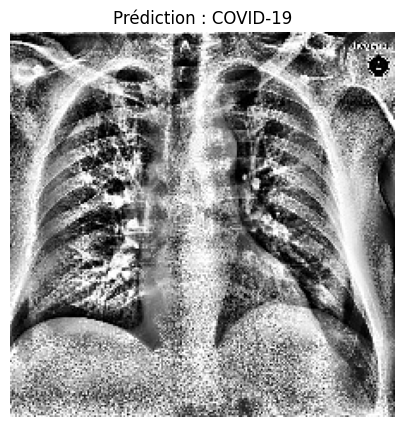

In [ ]:
# ============================================================
# PREDICTION SUR UNE IMAGE UPLOADEE (PALIER 3 – RESNET50)
# - Charge le modèle palier 3
# - Te permet de téléverser une image depuis ton PC
# - Affiche la maladie prédite + les scores
# ============================================================

!pip install -q torch torchvision opencv-python matplotlib

import os
import torch
import torch.nn as nn
from torchvision import transforms, models
import cv2
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive, files

# ==========================
# 1) MONTAGE DU DRIVE
# ==========================

drive.mount("/content/drive", force_remount=True)

# ==========================
# 2) CONFIG MODELE
# ==========================

# ✅ Ton modèle palier 3
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"

# ✅ Les classes dans le bon ordre
CLASSES = ["COVID-19", "No Finding", "Pneumonia", "Tuberculosis"]

IMG_SIZE = 224

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥 DEVICE utilisé :", device)

# ==========================
# 3) TRANSFORM POUR L'IMAGE
# ==========================

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # stats ImageNet
        std=[0.229, 0.224, 0.225],
    ),
])

# ==========================
# 4) CHARGEMENT DU MODELE
# ==========================

assert os.path.isfile(MODEL_PATH), f"❌ Modèle introuvable : {MODEL_PATH}"

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Modèle ResNet50 palier 3 chargé avec succès !")


# ==========================
# 5) FONCTION DE PREDICTION
# ==========================

def predict_image_array(img_bgr):
    """
    Prend une image en BGR (cv2) et renvoie :
    - classe prédite
    - scores softmax
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()

    pred_class = CLASSES[pred_idx]
    return pred_class, probs.cpu().numpy(), img_rgb


# ==========================
# 6) UPLOAD D'UNE IMAGE + PREDICTION
# ==========================

print("\n📂 Sélectionne une image depuis ton PC (PNG / JPG)...")
uploaded = files.upload()   # fenêtre d'upload

if len(uploaded) == 0:
    raise RuntimeError("❌ Aucune image uploadée.")

# On prend le premier fichier uploadé
file_name = list(uploaded.keys())[0]
img_path = os.path.join("/content", file_name)
print(f"\n🖼 Image reçue : {img_path}")

# Lire l'image avec OpenCV
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise RuntimeError(f"❌ Impossible de lire l'image : {img_path}")

# Prédiction
pred_class, probs, img_rgb = predict_image_array(img_bgr)

print("\n===== 🧠 PREDICTION =====")
print(f"🎯 Maladie prédite : {pred_class}")
print("\n📊 Scores par classe :")
for i, c in enumerate(CLASSES):
    print(f"  - {c:<12} : {probs[i]:.4f}")

# Affichage de l'image avec la prédiction
plt.figure(figsize=(5,5))
plt.imshow(img_rgb)
plt.title(f"Prédiction : {pred_class}")
plt.axis("off")
plt.show()


Mounted at /content/drive
🖥 DEVICE utilisé : cuda
✅ Modèle ResNet50 palier 3 chargé avec succès !

📂 Sélectionne une image depuis ton PC (PNG / JPG)...


Saving No Finding_hhlsr_prop_00014.png to No Finding_hhlsr_prop_00014.png

🖼 Image reçue : /content/No Finding_hhlsr_prop_00014.png

===== 🧠 PREDICTION DETAILLEE =====
✅ No illness detected (No Finding – 92.35 %)
🔎 Confidence level : High

📊 Scores par classe (probabilité d'appartenance) :
  - No Finding   : 92.35 %
  - COVID-19     : 7.63 %
  - Pneumonia    : 0.02 %
  - Tuberculosis : 0.00 %


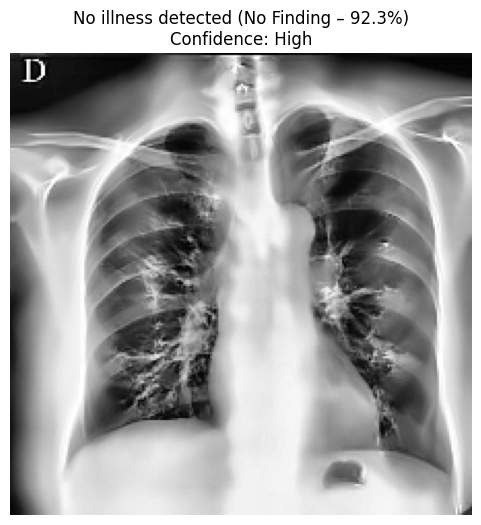

In [ ]:
# ============================================================
# PREDICTION SUR UNE IMAGE UPLOADEE (PALIER 3 – RESNET50)
# - Charge le modèle palier 3
# - Te permet de téléverser une image depuis ton PC
# - Affiche la maladie prédite + pourcentage + détails
# ============================================================

!pip install -q torch torchvision opencv-python matplotlib

import os
import torch
import torch.nn as nn
from torchvision import transforms, models
import cv2
import matplotlib.pyplot as plt
import numpy as np

from google.colab import drive, files

# ==========================
# 1) MONTAGE DU DRIVE
# ==========================

drive.mount("/content/drive", force_remount=True)

# ==========================
# 2) CONFIG MODELE
# ==========================

# ✅ Ton modèle palier 3
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"

# ✅ Les classes dans le bon ordre
CLASSES = ["COVID-19", "No Finding", "Pneumonia", "Tuberculosis"]

IMG_SIZE = 224

device = "cuda" if torch.cuda.is_available() else "cpu"
print("🖥 DEVICE utilisé :", device)

# ==========================
# 3) TRANSFORM POUR L'IMAGE
# ==========================

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],   # stats ImageNet
        std=[0.229, 0.224, 0.225],
    ),
])

# ==========================
# 4) CHARGEMENT DU MODELE
# ==========================

assert os.path.isfile(MODEL_PATH), f"❌ Modèle introuvable : {MODEL_PATH}"

model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))

state_dict = torch.load(MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model = model.to(device)
model.eval()

print("✅ Modèle ResNet50 palier 3 chargé avec succès !")


# ==========================
# 5) FONCTION DE PREDICTION
# ==========================

def predict_image_array(img_bgr):
    """
    Prend une image en BGR (cv2) et renvoie :
    - classe prédite
    - scores softmax (np.array)
    - image RGB (pour affichage)
    """
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img_tensor = transform(img_rgb).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_class = CLASSES[pred_idx]
    return pred_class, probs, img_rgb


# ==========================
# 6) UPLOAD D'UNE IMAGE + PREDICTION
# ==========================

print("\n📂 Sélectionne une image depuis ton PC (PNG / JPG)...")
uploaded = files.upload()   # fenêtre d'upload

if len(uploaded) == 0:
    raise RuntimeError("❌ Aucune image uploadée.")

# On prend le premier fichier uploadé
file_name = list(uploaded.keys())[0]
img_path = os.path.join("/content", file_name)
print(f"\n🖼 Image reçue : {img_path}")

# Lire l'image avec OpenCV
img_bgr = cv2.imread(img_path)
if img_bgr is None:
    raise RuntimeError(f"❌ Impossible de lire l'image : {img_path}")

# Prédiction
pred_class, probs, img_rgb = predict_image_array(img_bgr)

# Proba de la classe prédite
pred_idx = int(np.argmax(probs))
pred_prob = float(probs[pred_idx])
pred_percent = pred_prob * 100.0

# Déterminer si pathologie ou non
is_pathology = pred_class != "No Finding"

# Niveau de confiance
if pred_percent >= 85:
    confidence_level = "High"
elif pred_percent >= 65:
    confidence_level = "Medium"
else:
    confidence_level = "Low"

# ==========================
# 7) AFFICHAGE DETAILLE TEXTE
# ==========================

print("\n===== 🧠 PREDICTION DETAILLEE =====")

if is_pathology:
    print(f"🩺 Illness detected : {pred_class} ({pred_percent:.2f} %)")
else:
    print(f"✅ No illness detected (No Finding – {pred_percent:.2f} %)")

print(f"🔎 Confidence level : {confidence_level}")

print("\n📊 Scores par classe (probabilité d'appartenance) :")
for cls_name, p in sorted(zip(CLASSES, probs), key=lambda x: x[1], reverse=True):
    print(f"  - {cls_name:<12} : {p*100:.2f} %")

# ==========================
# 8) AFFICHAGE GRAPHIQUE
# ==========================

plt.figure(figsize=(6,6))
plt.imshow(img_rgb)
if is_pathology:
    title = f"Illness detected: {pred_class} ({pred_percent:.1f}%)\nConfidence: {confidence_level}"
else:
    title = f"No illness detected (No Finding – {pred_percent:.1f}%)\nConfidence: {confidence_level}"
plt.title(title)
plt.axis("off")
plt.show()


In [ ]:
# ============================================================
# CORRECTED ONNX EXPORT - Using Compatible Opset Version
# ============================================================

!pip install -q onnx onnxscript onnxruntime

import os
import torch
import torch.nn as nn
from torchvision import models
from google.colab import drive

drive.mount("/content/drive", force_remount=True)

# Paths
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"
EXPORT_DIR = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/model_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)
EXPORT_ONNX = os.path.join(EXPORT_DIR, "resnet50_hhlsr_api_3k_working.onnx")

CLASSES = ["COVID-19", "No Finding", "Pneumonia", "Tuberculosis"]

# 1. Reconstruct model
print("🔧 Reconstructing model...")
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))

# 2. Load weights
print("📥 Loading model weights...")
state_dict = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state_dict)
model.eval()
print("✅ Model loaded")

# 3. Test PyTorch model
print("\n🧪 Testing PyTorch model...")
dummy_input = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    pytorch_output = model(dummy_input)
    pytorch_probs = torch.softmax(pytorch_output, dim=1)
    print(f"   PyTorch output: {pytorch_probs.numpy()}")
    print(f"   Predicted: {CLASSES[pytorch_probs.argmax().item()]}")

# 4. Export to ONNX (USE OPSET 17 - stable version)
print("\n🚀 Exporting to ONNX...")
torch.onnx.export(
    model,
    dummy_input,
    EXPORT_ONNX,
    export_params=True,
    opset_version=17,              # ✅ Use opset 17 (stable)
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"}
    },
    # ✅ Disable dynamo for compatibility
    dynamo=False
)
print(f"✅ Export complete")

# 5. Verify ONNX
print("\n🔍 Verifying ONNX...")
import onnxruntime as ort
import numpy as np

sess = ort.InferenceSession(EXPORT_ONNX)
onnx_input = dummy_input.numpy().astype(np.float32)
onnx_output = sess.run(None, {"input": onnx_input})[0]
onnx_probs = torch.softmax(torch.from_numpy(onnx_output), dim=1).numpy()

print(f"   ONNX output:    {onnx_probs}")
print(f"   Predicted: {CLASSES[onnx_probs.argmax()]}")

# Compare
diff = np.abs(pytorch_probs.numpy() - onnx_probs).max()
print(f"\n   Max difference: {diff:.8f}")

if diff < 1e-5:
    print("   ✅ PERFECT MATCH! Export successful!")
elif diff < 0.001:
    print("   ✅ CLOSE MATCH (acceptable tolerance)")
else:
    print(f"   ❌ LARGE DIFFERENCE ({diff:.4f}) - Export may be incorrect!")

print(f"\n📁 Exported to: {EXPORT_ONNX}")

Mounted at /content/drive
🔧 Reconstructing model...
📥 Loading model weights...
✅ Model loaded

🧪 Testing PyTorch model...
   PyTorch output: [[0.2903329  0.07553834 0.6174302  0.01669859]]
   Predicted: Pneumonia

🚀 Exporting to ONNX...


/tmp/ipython-input-698629453.py:46: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


✅ Export complete

🔍 Verifying ONNX...
   ONNX output:    [[0.29033303 0.0755384  0.61743    0.01669861]]
   Predicted: Pneumonia

   Max difference: 0.00000024
   ✅ PERFECT MATCH! Export successful!

📁 Exported to: /content/drive/MyDrive/projet_medical/finale_version_salsebil/model_exports/resnet50_hhlsr_api_3k_working.onnx


In [ ]:
# ============================================================
# EXPORT EN ONNX DU MODÈLE FINAL (PALIER 3 – RESNET50)
# (avec installation de onnx + onnxscript)
# ============================================================

!pip install -q onnx onnxscript onnxruntime

import os
import torch
import torch.nn as nn
from torchvision import models

from google.colab import drive
drive.mount("/content/drive", force_remount=True)

# ⚠️ Chemin vers ton modèle palier 3 (déjà entraîné)
MODEL_PATH = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/classification_api/RESNET50_HHLSR_API_1K_2K_3K_20251206_222409/best_resnet50_hhlsr_api_1k_2k_3k.pth"

# 📂 Dossier d’export ONNX
EXPORT_DIR = "/content/drive/MyDrive/projet_medical/finale_version_salsebil/model_exports"
os.makedirs(EXPORT_DIR, exist_ok=True)

EXPORT_ONNX = os.path.join(EXPORT_DIR, "resnet50_hhlsr_api_3k_final.onnx")

# Les classes dans le bon ordre
CLASSES = ["COVID-19", "No Finding", "Pneumonia", "Tuberculosis"]

print("🖥 DEVICE utilisé pour la reconstruction :", "cpu")

# 1) Reconstruire le modèle exactement comme à l'entraînement
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))

assert os.path.isfile(MODEL_PATH), f"❌ Modèle introuvable : {MODEL_PATH}"
state = torch.load(MODEL_PATH, map_location="cpu")
model.load_state_dict(state)
model.eval()

print("✅ Modèle chargé, prêt pour l'export ONNX.")

# 2) Dummy input (same shape as training)
dummy = torch.randn(1, 3, 224, 224)

# 3) EXPORT ONNX
print("🚀 Export ONNX en cours...")
torch.onnx.export(
    model,
    dummy,
    EXPORT_ONNX,
    input_names=["input"],
    output_names=["output"],
    opset_version=12,
    dynamic_axes={"input": {0: "batch"}, "output": {0: "batch"}},
)

print("🎉 EXPORT ONNX TERMINÉ AVEC SUCCÈS !")
print("📁 Fichier ONNX :", EXPORT_ONNX)


Mounted at /content/drive
🖥 DEVICE utilisé pour la reconstruction : cpu


/tmp/ipython-input-2776849038.py:46: UserWarning: # 'dynamic_axes' is not recommended when dynamo=True, and may lead to 'torch._dynamo.exc.UserError: Constraints violated.' Supply the 'dynamic_shapes' argument instead if export is unsuccessful.
  torch.onnx.export(
W1207 20:34:18.258000 1064 torch/onnx/_internal/exporter/_compat.py:114] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features


✅ Modèle chargé, prêt pour l'export ONNX.
🚀 Export ONNX en cours...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 127, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 122, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_str, target_version)
                          ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
RuntimeError: /github/workspace/onnx/version_converter/adapters/axes_input_to_attribute.h:65: adapt: Asserti

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Applied 106 of general pattern rewrite rules.
🎉 EXPORT ONNX TERMINÉ AVEC SUCCÈS !
📁 Fichier ONNX : /content/drive/MyDrive/projet_medical/finale_version_salsebil/model_exports/resnet50_hhlsr_api_3k_final.onnx
